Ejercicio 1.

a) Los puntos de control son:
    * P3 = (0,0)
    * P0 = (0.5, 1)
Los puntos de control P0 y P3 delimitan el comienzo y el fin de la curva. Por eso, para saber cuales son, simplemente nos fijamos el primer y ultimo punto de la curva.

b) Las transofrmaciones lineales necesarias son:
    2. Para cada pétalo: aplicar una rotación de k×60°
    3. El pétalo "espejado" del mismo ángulo: aplicar la misma rotación + reflexión

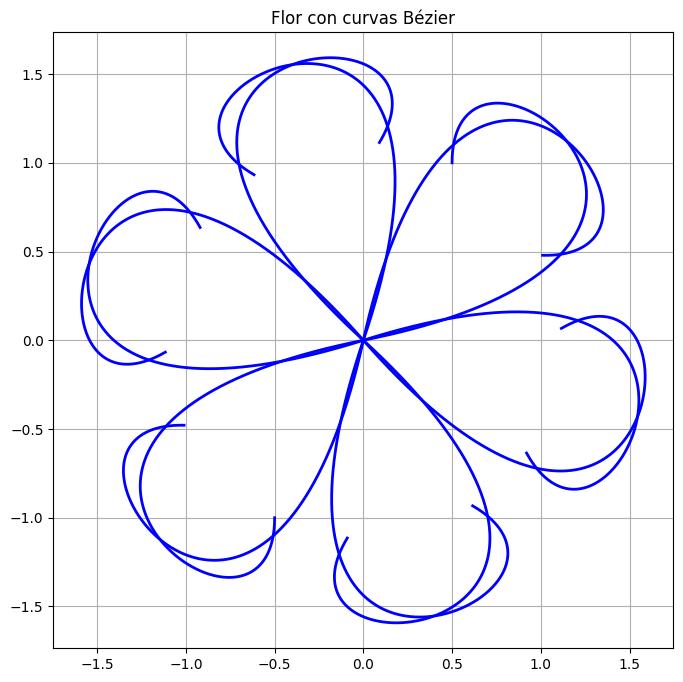

In [36]:
import numpy as np
import matplotlib.pyplot as plt


# -------------------------
# Bézier cúbica
# -------------------------
def bezier(P0, P1, P2, P3, n=300):
    t = np.linspace(0, 1, n)

    return ((1 - t)**3)[:, None] * P0 + \
           3*((1 - t)**2 * t)[:, None] * P1 + \
           3*((1 - t) * t**2)[:, None] * P2 + \
           (t**3)[:, None] * P3


# -------------------------
# Rotación
# -------------------------
def rotar(curva, ang):
    th = np.radians(ang)

    R = np.array([
        [np.cos(th), -np.sin(th)],
        [np.sin(th),  np.cos(th)]
    ])

    return curva @ R.T


# -------------------------
# Reflexión respecto
# de una recta por el origen
# -------------------------
def reflejar(curva, eje):
    u = eje / np.linalg.norm(eje)

    M = 2*np.outer(u, u) - np.eye(2)

    return curva @ M.T


# -------------------------
# Puntos de control
# -------------------------
P0 = np.array([0.5, 1.0])
P1 = np.array([2.5, 0.5])
P2 = np.array([0.5, 2.0])
P3 = np.array([0.0, 0.0])


# curva original
c1 = bezier(P3, P1, P2, P0)


# -------------------------
# eje del pétalo
# alpha controla ancho:
# 1 -> más fino
# 0 -> más ancho
# -------------------------
alpha = 0.7

# el eje apunta al promedio de los controles internos
eje = alpha * ((P1 + P2)/2) + (1-alpha) * P0


# curva espejada
c2 = reflejar(c1, eje)


# -------------------------
# generar flor
# -------------------------
curvas = []

for ang in range(0, 360, 60):
    curvas.append(rotar(c1, ang))
    curvas.append(rotar(c2, ang))


# -------------------------
# dibujar
# -------------------------
plt.figure(figsize=(8,8))

for c in curvas:
    plt.plot(c[:,0], c[:,1], 'b', lw=2)

plt.axis("equal")
plt.grid()
plt.title("Flor con curvas Bézier")
plt.show()




segmentos = []

for ang in range(0, 360, 60):

    # curva original
    q0 = rotar(P3, ang)
    q1 = rotar(P1, ang)
    q2 = rotar(P2, ang)
    q3 = rotar(P0, ang)

    segmentos.append([
        float(q0[0]), float(q0[1]),
        float(q1[0]), float(q1[1]),
        float(q2[0]), float(q2[1]),
        float(q3[0]), float(q3[1])
    ])

    # curva reflejada REAL
    q0r = rotar(P3r, ang)
    q1r = rotar(P1r, ang)
    q2r = rotar(P2r, ang)
    q3r = rotar(P0r, ang)

    segmentos.append([
        float(q0r[0]), float(q0r[1]),
        float(q1r[0]), float(q1r[1]),
        float(q2r[0]), float(q2r[1]),
        float(q3r[0]), float(q3r[1])
    ])



In [37]:
import pprint

with open("flor.txt","w") as f:
    pprint.pprint(segmentos, stream=f)

In [38]:
!python bezier_to_svg.py flor.txt --mostrar-controles

Se cargaron 12 segmento(s) de Bézier desde 'flor.txt'.
SVG guardado en 'flor.svg'.
